# Numerical Simulation Laboratory - Notebook 6

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

## Exercise 06.1

In [2]:

# Calculations for theoretical curves
def theoretical_curves(T):
        b = 1/T
        J = 1.0
        h = 0.02
        Ns = 50
        th = np.tanh(J/T)
        thN= th**Ns
        ch = 1/th
        e = -J*( th + ch*thN )/( 1 + thN )
        heat=((b*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)
        l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
        l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
        Z = l1**Ns + l2**Ns
        M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
                + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
        X = b*np.exp(2*b*J)*(1-thN)/(1+thN)

        return [e, heat, X, M]
    
points=100
temps = np.arange(0.5,2.1,0.1)
T = np.linspace(0.2,2.3,num=points)


total_energy_metr = np.array([np.loadtxt(f"../NSL_SIMULATOR/OUTPUT-METROPOLIS/total_energy_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])
total_energy_gibbs = np.array([np.loadtxt(f"../NSL_SIMULATOR/OUTPUT-GIBBS/total_energy_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])

cv_metr = np.array([np.loadtxt(f"../NSL_SIMULATOR/OUTPUT-METROPOLIS/specific_heat_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])
cv_gibbs = np.array([np.loadtxt(f"../NSL_SIMULATOR/OUTPUT-GIBBS/specific_heat_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])

chi_metr = np.array([np.loadtxt(f"../NSL_SIMULATOR/OUTPUT-METROPOLIS/susceptibility_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])
chi_gibbs = np.array([np.loadtxt(f"../NSL_SIMULATOR/OUTPUT-GIBBS/susceptibility_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])

magnet_metr = np.array([np.loadtxt(f"../NSL_SIMULATOR/OUTPUT-METROPOLIS/magnetization_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])
magnet_gibbs = np.array([np.loadtxt(f"../NSL_SIMULATOR/OUTPUT-GIBBS/magnetization_{temp:.1f}.dat", usecols=(2,3))[-1] for temp in temps])

Reduced chi^2 Ising 1D, Internal energy, Metropolis: 0.76
Reduced chi^2 Ising 1D, Internal energy, Gibbs: 0.76
Reduced chi^2 Ising 1D, Heat capacity, Metropolis: 1.31
Reduced chi^2 Ising 1D, Heat capacity, Gibbs: 1.31
Reduced chi^2 Ising 1D, Susceptibility, Metropolis: 0.93
Reduced chi^2 Ising 1D, Susceptibility, Gibbs: 0.93
Reduced chi^2 Ising 1D, Magnetization with $h = 0.02$, Metropolis: 1.13
Reduced chi^2 Ising 1D, Magnetization with $h = 0.02$, Gibbs: 1.13


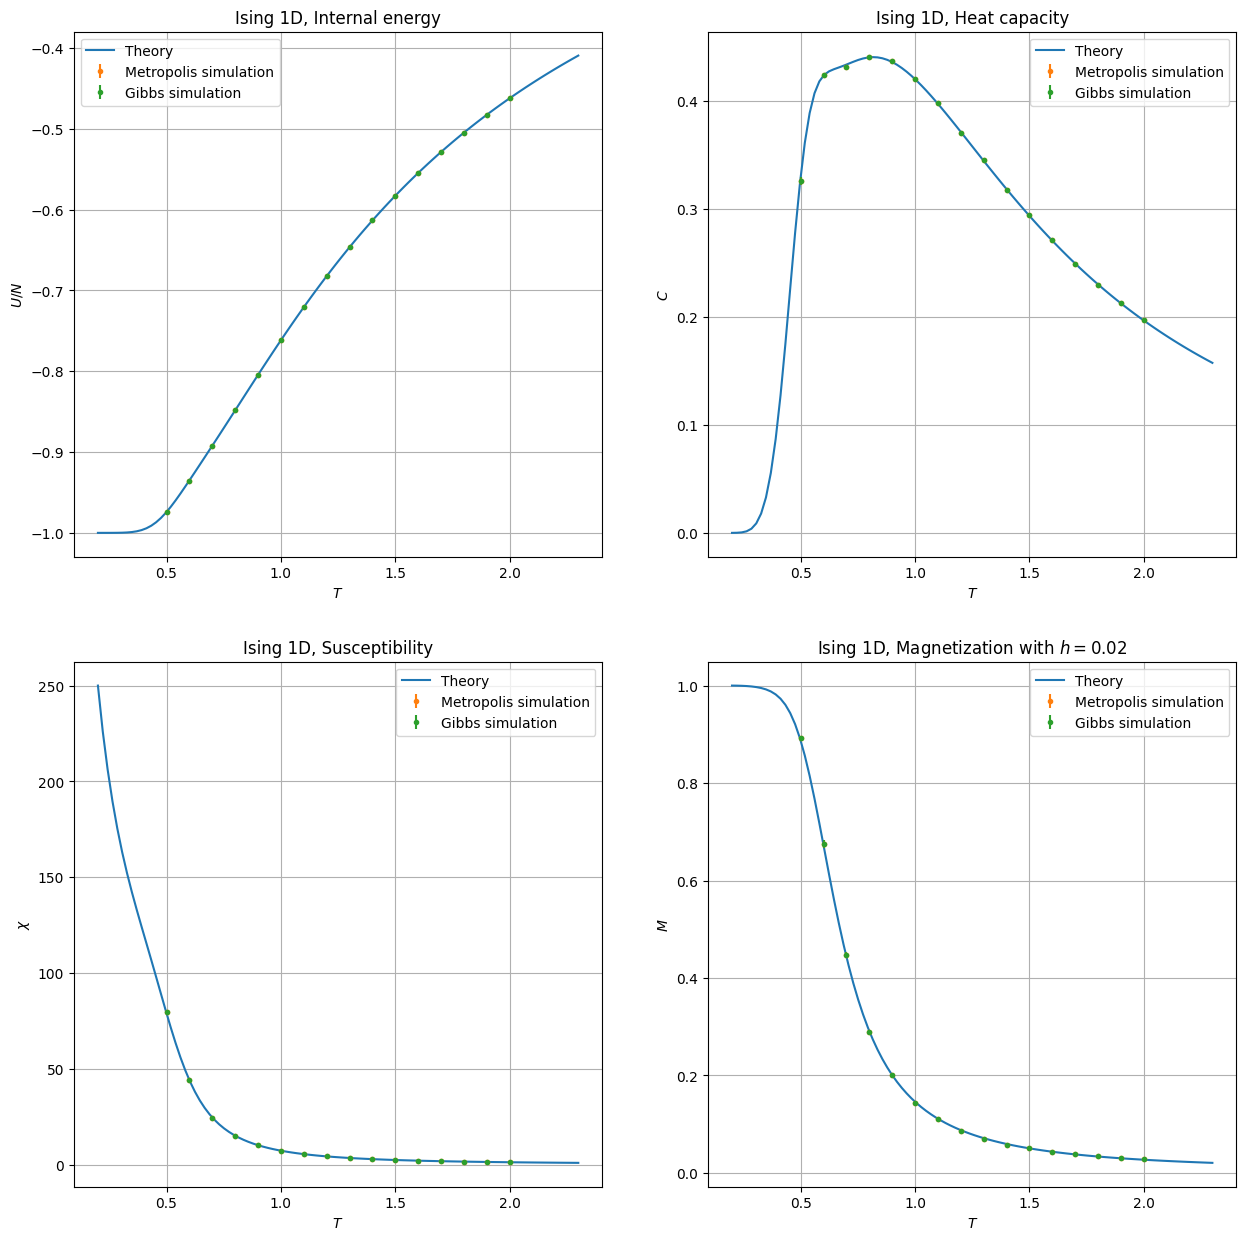

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(15,15))
ax = ax.flatten()

theory = theoretical_curves(T)
expected = theoretical_curves(temps)
metropolis = [total_energy_metr, cv_metr, chi_metr, magnet_metr]
gibbs = [total_energy_gibbs, cv_gibbs, chi_gibbs, magnet_gibbs]
ylabels = ["$U/N$", "$C$", "$\\chi$", "$M$"]
titles = ["Ising 1D, Internal energy", "Ising 1D, Heat capacity", "Ising 1D, Susceptibility", "Ising 1D, Magnetization with $h = 0.02$"]
# Internal energy
for i in range(4):
    ax[i].plot(T, theory[i], label="Theory")
    ax[i].errorbar(temps, metropolis[i][:,0], yerr=metropolis[i][:,1], fmt=".", label="Metropolis simulation")
    ax[i].errorbar(temps, gibbs[i][:,0], yerr=gibbs[i][:,1], fmt=".", label="Gibbs simulation")

    ax[i].set_title(titles[i])
    ax[i].set_xlabel('$T$')
    ax[i].set_ylabel(ylabels[i])
    ax[i].grid()
    ax[i].legend();
    print(f"Reduced chi^2 {titles[i]}, Metropolis: {np.sum(((expected[i]-metropolis[i][:,0])/metropolis[i][:,1])**2)/metropolis[i][:,0].size:.2f}")
    print(f"Reduced chi^2 {titles[i]}, Gibbs: {np.sum(((expected[i]-gibbs[i][:,0])/gibbs[i][:,1])**2)/gibbs[i][:,0].size:.2f}")


A Pyhton script was written to automatically execute all the necessary simulations. It can be found in `NSL_SIMULATOR\SOURCE\exercise06.1.py`. The script runs the simulations changing the temperature from $T=2.0$ to $T=0.5$ with steps of $\Delta T=0.1$. For each temperature first it runs a shorter simulation for the equilibration of the system, then it copies the final configuration and starts a longer simulation to compute the measurements. After this simulation the final configuration is copied again to the input, to facilitate the equilibration of the following temperature, and the files containing to the measured quantities are moved to another folder. When the temperature decreases the the simulation needs more steps to generate precise measurements, so the number of steps in each block increases with a law $N(T)=N_0(1.1)^\frac{T_0-T}{\Delta T}$, where $N_0=20000$ and $T_0=2.0$. For each temperature the simulations are repeated 4 times: 2 with the Metropolis algorithm (with $h=0$ and $h=0.02$) and 2 with the Gibbs algorithm (also with $h=0$ and $h=0.02$).

The figure above shows that both algorithms return measurements that lie on the theoretical curve for each of the 4 measured quantities. All the reduced $\chi^2$ of the fit of the data with the theoretical curve are close to $1$, which confirms the goodness of the fit. The measurements coming from the two algorithms are very close, which is why the data points overlap in the figure.